# 4. Preprocessing & Feature Engineering
**Project:** HR Analytics: Employee Attrition  

---

## Overview
Transformation of raw data into a clean, fully numeric, model-ready dataset. Every decision is documented in the Decision Log at the bottom. All imputation statistics are fit on training data only.

## Contents
1. Setup
2. Drop ID Column
3. Ordinal Encoding (manual)
4. Missing Value Handling
5. Missing Indicator Flags
6. One-Hot Encoding (nominal)
7. Log-Transform Skewed Features
8. Feature Engineering
9. Drop Redundant Columns
10. Validation Assertions
11. Save Processed Datasets
12. Decision Log

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append('..')
import warnings
from src.data_utils import (
    encode_experience, encode_last_new_job, encode_company_size,
    encode_education, add_missing_indicators, add_career_stage,
    add_stability_score, add_upskilling_intensity, validate_preprocessed
)

warnings.filterwarnings('ignore')

train = pd.read_csv('../data/raw/aug_train.csv')
test  = pd.read_csv('../data/raw/aug_test.csv')

df_train = train.copy()
df_test  = test.copy()

print('Train shape:', df_train.shape)
print('Test shape: ', df_test.shape)

Train shape: (19158, 14)
Test shape:  (2129, 13)


## 2. Drop ID Column
Let's first drop the ID column to prevent accidental inclusion in any downstream operation.

In [2]:
df_train = df_train.drop(columns=['enrollee_id'])
df_test  = df_test.drop(columns=['enrollee_id'])
print('enrollee_id dropped. Shapes:', df_train.shape, df_test.shape)

enrollee_id dropped. Shapes: (19158, 13) (2129, 12)


## 3. Ordinal Encoding
These columns contain ordered categories represented as strings. `LabelEncoder` would assign alphabetical integers, destroying ordinal meaning. Manual maps preserve the true order.

In [3]:
# experience: <1→0, 1–20→1–20, >20→21
df_train['experience_num'] = encode_experience(df_train['experience'])
df_test['experience_num']  = encode_experience(df_test['experience'])

# last_new_job: never→0, 1–4→1–4, >4→5
df_train['last_new_job_num'] = encode_last_new_job(df_train['last_new_job'])
df_test['last_new_job_num']  = encode_last_new_job(df_test['last_new_job'])

# company_size: ordinal 1–8, unknown→0
df_train['company_size_num'] = encode_company_size(df_train['company_size'])
df_test['company_size_num']  = encode_company_size(df_test['company_size'])

# education_level: Primary→1, HS→2, Graduate→3, Masters→4, PhD→5
df_train['education_num'] = encode_education(df_train['education_level'])
df_test['education_num']  = encode_education(df_test['education_level'])

# Quick verification - NaN counts must match originals
for col, enc in [('experience','experience_num'),
                 ('last_new_job','last_new_job_num')]:
    assert (df_train[col].isnull().sum() ==
            df_train[enc].isnull().sum()), f'NaN mismatch in {enc}'

print('Ordinal encoding complete. Sample:')
df_train[['experience','experience_num',
          'last_new_job','last_new_job_num']].head(8)

Ordinal encoding complete. Sample:


,experience,experience_num,last_new_job,last_new_job_num
0,>20,21.0,1,1.0
1,15,15.0,>4,5.0
2,5,5.0,never,0.0
3,<1,0.0,never,0.0
4,>20,21.0,4,4.0
5,11,11.0,1,1.0
6,5,5.0,1,1.0
7,13,13.0,>4,5.0


## 4. Missing Value Handling

In [4]:
# --- Unknown category for demographic/identity columns ---
for col in ['gender', 'company_type', 'major_discipline']:
    df_train[col] = df_train[col].fillna('Unknown')
    df_test[col]  = df_test[col].fillna('Unknown')

# --- Enrolled university: mode imputation (<2% missing) ---
enroll_mode = df_train['enrolled_university'].mode()[0]
df_train['enrolled_university'] = df_train['enrolled_university'].fillna(enroll_mode)
df_test['enrolled_university']  = df_test['enrolled_university'].fillna(enroll_mode)

# --- education_num: median imputation ---
edu_median = df_train['education_num'].median()
df_train['education_num'] = df_train['education_num'].fillna(edu_median)
df_test['education_num']  = df_test['education_num'].fillna(edu_median)

# --- experience_num: median imputation ---
exp_median = df_train['experience_num'].median()
df_train['experience_num'] = df_train['experience_num'].fillna(exp_median)
df_test['experience_num']  = df_test['experience_num'].fillna(exp_median)

# --- last_new_job_num: mode imputation ---
lnj_mode = df_train['last_new_job_num'].mode()[0]
df_train['last_new_job_num'] = df_train['last_new_job_num'].fillna(lnj_mode)
df_test['last_new_job_num']  = df_test['last_new_job_num'].fillna(lnj_mode)

# company_size_num: 0 already used as 'Unknown' sentinel - no extra fillna needed

print('Post-imputation null check (train):')
nulls = df_train[['gender','company_type','major_discipline',
                  'enrolled_university','education_num',
                  'experience_num','last_new_job_num',
                  'company_size_num']].isnull().sum()
print(nulls)

Post-imputation null check (train):
gender                 0
company_type           0
major_discipline       0
enrolled_university    0
education_num          0
experience_num         0
last_new_job_num       0
company_size_num       0
dtype: int64


## 5. Missing Indicator Flags
Missingness in `company_type`, `company_size`, and `gender` correlates with target.

In [5]:
df_train = add_missing_indicators(
    df_train, train,
    cols=['company_type', 'company_size', 'gender']
)
df_test = add_missing_indicators(
    df_test, test,
    cols=['company_type', 'company_size', 'gender']
)

print('Missing indicator columns added:')
df_train[['company_type_was_missing',
          'company_size_was_missing',
          'gender_was_missing']].mean().round(3)

Missing indicator columns added:


company_type_was_missing    0.320
company_size_was_missing    0.310
gender_was_missing          0.235
dtype: float64

## 6. One-Hot Encoding (nominal columns)

In [6]:
nominal_cols = ['gender', 'relevent_experience', 'enrolled_university',
                'major_discipline', 'company_type']

df_train = pd.get_dummies(df_train, columns=nominal_cols, drop_first=False)
df_test  = pd.get_dummies(df_test,  columns=nominal_cols, drop_first=False)

y_train = df_train.pop('target')
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)
df_train['target'] = y_train.values

print('After one-hot encoding:')
print('  Train:', df_train.shape)
print('  Test: ', df_test.shape)

After one-hot encoding:
  Train: (19158, 38)
  Test:  (2129, 37)


## 7. Log-Transform Skewed Features

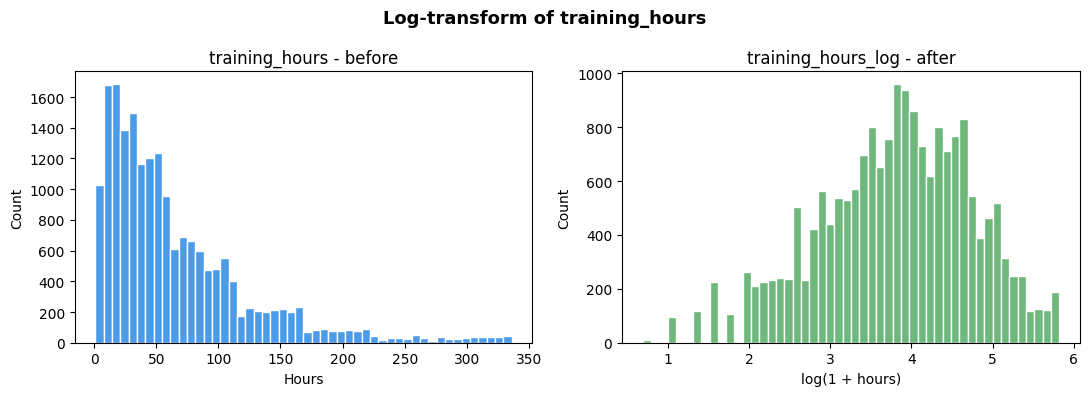

training_hours replaced by training_hours_log


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_train['training_hours'], bins=50, color='#4C9BE8', edgecolor='white')
axes[0].set_title('training_hours - before')
axes[0].set_xlabel('Hours')

df_train['training_hours_log'] = np.log1p(df_train['training_hours'])
df_test['training_hours_log']  = np.log1p(df_test['training_hours'])

axes[1].hist(df_train['training_hours_log'], bins=50, color='#6DB87A', edgecolor='white')
axes[1].set_title('training_hours_log - after')
axes[1].set_xlabel('log(1 + hours)')
for ax in axes: ax.set_ylabel('Count')

plt.suptitle('Log-transform of training_hours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/13_log_transform_effect.png', bbox_inches='tight', dpi=150)
plt.show()

# Drop original
df_train = df_train.drop(columns=['training_hours'])
df_test  = df_test.drop(columns=['training_hours'])
print('training_hours replaced by training_hours_log')

## 8. Feature Engineering

In [8]:
# career_stage_num: Early=0, Mid=1, Senior=2
# EDA showed non-linear attrition arc; bucketing captures this
df_train = add_career_stage(df_train)
df_test  = add_career_stage(df_test)

# stability_score: (company_size/8 + last_new_job/5) / 2
# Combines two correlated stability signals into one bounded [0,1] feature
df_train = add_stability_score(df_train)
df_test  = add_stability_score(df_test)

# upskilling_intensity: log(hours) / (experience + 1)
# Normalizes training investment by career stage
df_train = add_upskilling_intensity(df_train)
df_test  = add_upskilling_intensity(df_test)

new_feats = ['career_stage_num', 'stability_score', 'upskilling_intensity']
print('Engineered feature summary:')
display(df_train[new_feats].describe().round(3))
print('\nNull check:')
print(df_train[new_feats].isnull().sum())

Engineered feature summary:


,career_stage_num,stability_score,upskilling_intensity
count,19158.000,19158.000,19158.000
mean,1.216,0.381,0.604
std,0.735,0.259,0.686
min,0.000,0.000,0.032
25%,1.000,0.162,0.223
50%,1.000,0.350,0.389
75%,2.000,0.562,0.711
max,2.000,1.000,5.820



Null check:
career_stage_num        0
stability_score         0
upskilling_intensity    0
dtype: int64


## 9. Drop Redundant Columns

In [9]:
# Drop original string columns replaced by numeric versions
# Drop 'city' - high cardinality; CDI already captures the city-level signal
cols_to_drop = ['experience', 'last_new_job', 'company_size',
                'education_level', 'city']

for col in cols_to_drop:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])
    if col in df_test.columns:
        df_test  = df_test.drop(columns=[col])

print('Final shapes:')
print('  Train:', df_train.shape)
print('  Test: ', df_test.shape)

Final shapes:
  Train: (19158, 36)
  Test:  (2129, 35)


## 10. Validation Assertions

In [10]:
validate_preprocessed(df_train, df_test)

PREPROCESSING VALIDATION REPORT
✓ No missing values in train or test
✓ All columns are numeric
✓ Target column correct (present in train, absent in test)
✓ Train and test columns are aligned
✓ No ID column present
✓ stability_score bounded [0, 1]
Feature count : 35
Training rows : 19,158
Test rows     : 2,129
ALL CHECKS PASSED - ready to save


True

## 11. Save Processed Datasets

In [11]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)

df_train.to_csv('../data/processed/hr_train_clean.csv', index=False)
df_test.to_csv( '../data/processed/hr_test_clean.csv',  index=False)

print('Saved:')
print('  data/processed/hr_train_clean.csv')
print('  data/processed/hr_test_clean.csv')
print()
print('Train columns:', df_train.shape[1])
print(df_train.dtypes.value_counts())

Saved:
  data/processed/hr_train_clean.csv
  data/processed/hr_test_clean.csv

Train columns: 36
bool       23
float64     9
int32       3
int64       1
Name: count, dtype: int64


---
## 12. Preprocessing Decision Log

| Column | Action | Reason |
|---|---|---|
| `enrollee_id` | Dropped | Row identifier - no predictive value |
| `experience` | Manual ordinal encoding (<1→0, >20→21) | String ranges; LabelEncoder would destroy order |
| `last_new_job` | Manual ordinal encoding (never→0, >4→5) | String sentinels require custom map |
| `company_size` | Manual ordinal encoding (1–8), Unknown→0 | Band order is meaningful |
| `education_level` | Manual ordinal encoding (1–5) | Natural academic progression |
| `gender` | One-hot + `was_missing` flag | Nominal; missingness correlated with target |
| `company_type` | One-hot + `was_missing` flag | Nominal; missingness correlated with target |
| `company_size` | `was_missing` flag added | 31% missing; missingness correlated with target |
| `major_discipline` | One-hot (Unknown as category) | Nominal; no natural order |
| `enrolled_university` | One-hot | Nominal |
| `relevent_experience` | One-hot | Binary; kept as dummy for interpretability |
| `training_hours` | log1p transform; original dropped | Right-skewed; log normalizes distribution |
| `city` | Dropped | 123 unique levels; CDI captures relevant signal |
| `career_stage_num` | Engineered from `experience_num` | Captures non-linear career arc from EDA |
| `stability_score` | Engineered (company_size + tenure, normalized) | Composite bounded signal; both vars predictive |
| `upskilling_intensity` | Engineered (log_hours / experience+1) | Relative training investment controlling for stage |

**Imputation rules:**
- All statistics (median, mode) computed on TRAIN only, applied to TRAIN + TEST
- `gender`, `company_type`, `major_discipline` encoded as 'Unknown' - imputation would introduce false signal
- `company_size_num` uses 0 as Unknown (outside the 1–8 ordinal range, distinguishable)